### 1. Introduction

1.1. Student Name  : <b>Vishal Chaudhary</b> <br> 


### <b>2. Extended Simulation Model for 30 days<b> 

In [1]:
# Import all libraries
import simpy
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Dict
from dataclasses import dataclass
from datetime import datetime, timedelta

In [2]:
# defining the data class
@dataclass
class DailyOperationResult:
    day: int
    containers_generated: int
    containers_shipped: int
    containers_failed: int
    success_rate: float
    truck_utilization: float
    crane_utilization: float
    max_buffer_used: int
    avg_buffer_level: float

In [3]:
# defining the class for simulation that contains extended resources and time

class ExtendedContainerTransportSimulation:
    """30-Day simulation model for Chifeng Gold container transport
    Step 5a: steady state with minimal variability || Step 5b: increased variability with robustness testing"""
    
    def __init__(self, trucks, cranes, buffer_capacity, variability_level="minimal"):
        self.trucks = trucks
        self.cranes = cranes
        self.buffer_capacity = buffer_capacity
        self.variability_level = variability_level
        
        # service time parameters based on variability level
        if variability_level == "minimal":
            # Step 5a: Minimal variability
            self.mine_loading_std = 0.5    
            self.travel_time_std = 1.0     
            self.crane_service_std = 0.5   
            self.demand_variability = 0.05  
        else:
            # increased variability (realistic)
            self.mine_loading_std = 2.0    
            self.travel_time_std = 5.0     
            self.crane_service_std = 2.0   
            self.demand_variability = 0.15  
            
        # base service times
        self.mine_loading_mean = 5
        self.truck_travel_mean = 25
        self.truck_return_mean = 20
        self.crane_service_mean = 6
        
        # monthly tracking
        self.daily_results = []
        self.monthly_stats = {}
        
    def simulate_single_day(self, day, target_containers):
        """operations simulation for a single day"""
        
        # setting daily random seed for reproducibility
        np.random.seed(42 + day)
        random.seed(42 + day)
        
        env = simpy.Environment()
        
        # creating   daily resources
        trucks = simpy.Resource(env, capacity=self.trucks)
        cranes = simpy.Resource(env, capacity=self.cranes)  
        buffer_storage = simpy.Container(env, capacity=self.buffer_capacity, init=0)
        
        # daily tracking variables
        containers_at_mine = 0
        containers_shipped = 0
        containers_failed = 0
        truck_busy_time = 0
        crane_busy_time = 0
        max_buffer_used = 0
        buffer_history = []
        
        def container_process(container_id, arrival_time):
            """process single container through the system"""
            nonlocal containers_shipped, containers_failed, truck_busy_time, crane_busy_time, max_buffer_used
            
            # phase 1: truck transport
            with trucks.request() as truck_req:
                yield truck_req
                
                truck_start = env.now
                
                # load at mine (with variability)
                loading_time = max(2, np.random.normal(self.mine_loading_mean, self.mine_loading_std))
                yield env.timeout(loading_time)
                
                # travel to terminal
                travel_time = max(15, np.random.normal(self.truck_travel_mean, self.travel_time_std))
                yield env.timeout(travel_time)
                
                # return to mine
                return_time = max(12, np.random.normal(self.truck_return_mean, self.travel_time_std))
                yield env.timeout(return_time)
                
                truck_end = env.now
                truck_busy_time += (truck_end - truck_start)
            
            # phase 2: buffer storage
            if buffer_storage.level >= buffer_storage.capacity:
                containers_failed += 1
                return
                
            yield buffer_storage.put(1)
            max_buffer_used = max(max_buffer_used, buffer_storage.level)
            
            # phase 3: crane loading
            if env.now > 450:  
                containers_failed += 1
                yield buffer_storage.get(1)  
                return
                
            with cranes.request() as crane_req:
                yield crane_req
                
                crane_start = env.now
                yield buffer_storage.get(1)  
                
                # crane service time
                service_time = max(3, np.random.normal(self.crane_service_mean, self.crane_service_std))
                yield env.timeout(service_time)
                
                crane_end = env.now
                crane_busy_time += (crane_end - crane_start)
                containers_shipped += 1
        
        def mine_production():
            """generate containers throughout the day"""
            actual_target = int(target_containers * (1 + np.random.uniform(-self.demand_variability, self.demand_variability)))
            actual_target = max(1, min(actual_target, 120))  
            
            # generate containers over 300 minutes
            production_window = 300
            if actual_target > 0:
                base_interval = production_window / actual_target
                
                for i in range(actual_target):
                    if self.variability_level == "minimal":
                        interval_var = np.random.uniform(0.9, 1.1) 
                    else:
                        interval_var = np.random.uniform(0.7, 1.3)  
                    
                    next_interval = base_interval * interval_var
                    
                    if i > 0:
                        yield env.timeout(next_interval)
                    
                    if env.now < production_window:
                        container_id = f"D{day:02d}C{i+1:03d}"
                        env.process(container_process(container_id, env.now))
        
        def monitor_buffer():
            """monitor buffer levels throughout the day"""
            while env.now < 480:
                buffer_history.append(buffer_storage.level)
                yield env.timeout(5)  
        
        # start daily processes
        env.process(mine_production())
        env.process(monitor_buffer())
        
        # run day simulation (8 hours = 480 minutes)
        env.run(until=480)
        
        # calculate daily metrics
        total_generated = containers_shipped + containers_failed
        success_rate = (containers_shipped / total_generated * 100) if total_generated > 0 else 0
        truck_utilization = (truck_busy_time / (self.trucks * 480)) * 100
        crane_utilization = (crane_busy_time / (self.cranes * 480)) * 100
        avg_buffer_level = np.mean(buffer_history) if buffer_history else 0
        
        return DailyOperationResult(day=day,containers_generated=total_generated,containers_shipped=containers_shipped,
                                    containers_failed=containers_failed,success_rate=success_rate,truck_utilization=truck_utilization,
                                    crane_utilization=crane_utilization,max_buffer_used=max_buffer_used,avg_buffer_level=avg_buffer_level)
    
    def run_30_day_simulation(self, daily_target=91):
        """run complete 30-day simulation"""
        
        
        print(f"\n 30-Day simulation: {self.variability_level.upper()} variability")
        print(f"\n Configuration: {self.trucks} trucks, {self.cranes} cranes, {self.buffer_capacity} FEU buffer")
        print(f"\n Daily target: {daily_target} containers")
        
        
        self.daily_results = []
        
        # show progress for longer simulation
        print("Simulating days: ", end="")
        
        for day in range(1, 31):
            if day % 5 == 0 or day == 1:
                print(f"{day}", end=" ")
            
            # simulate single day
            daily_result = self.simulate_single_day(day, daily_target)
            self.daily_results.append(daily_result)
        
        print("- Complete!")
        
        # calculate monthly statistics
        self.calculate_monthly_statistics()
        
        return self.daily_results
    
    def calculate_monthly_statistics(self):
        """calculate   monthly performance statistics"""
        
        # basic aggregations
        total_generated = sum(r.containers_generated for r in self.daily_results)
        total_shipped = sum(r.containers_shipped for r in self.daily_results)
        total_failed = sum(r.containers_failed for r in self.daily_results)
        
        # daily performance arrays
        daily_shipped = [r.containers_shipped for r in self.daily_results]
        daily_success_rates = [r.success_rate for r in self.daily_results]
        daily_truck_util = [r.truck_utilization for r in self.daily_results]
        daily_crane_util = [r.crane_utilization for r in self.daily_results]
        daily_max_buffer = [r.max_buffer_used for r in self.daily_results]
        
        # calculate statistics
        self.monthly_stats = {
            # throughput metrics
            'total_containers_generated': total_generated,'total_containers_shipped': total_shipped,'total_containers_failed': total_failed,
            'monthly_success_rate': (total_shipped / total_generated * 100) if total_generated > 0 else 0,
            'monthly_target_achievement': (total_shipped / (91 * 30)) * 100,  
            
            # daily performance statistics
            'avg_daily_shipped': np.mean(daily_shipped),'std_daily_shipped': np.std(daily_shipped),
            'min_daily_shipped': np.min(daily_shipped),'max_daily_shipped': np.max(daily_shipped),
            
            # success rate statistics
            'avg_daily_success_rate': np.mean(daily_success_rates),'min_daily_success_rate': np.min(daily_success_rates),
            'days_below_90_percent': sum(1 for rate in daily_success_rates if rate < 90),
            
            # resource utilization
            'avg_truck_utilization': np.mean(daily_truck_util),'avg_crane_utilization': np.mean(daily_crane_util),
            'max_truck_utilization': np.max(daily_truck_util),'max_crane_utilization': np.max(daily_crane_util),
            
            # buffer performance
            'avg_max_buffer_used': np.mean(daily_max_buffer),'max_buffer_used_overall': np.max(daily_max_buffer),
            'buffer_utilization': (np.max(daily_max_buffer) / self.buffer_capacity) * 100,
            
            # reliability metrics
            'days_meeting_target': sum(1 for shipped in daily_shipped if shipped >= 91),
            'operational_reliability': (sum(1 for rate in daily_success_rates if rate >= 95) / 30) * 100}
    
    def monthly_report(self):
        """Print comprehensive monthly performance report"""
        
        stats = self.monthly_stats
        
        
        print(f"\n 30-DAY PERFORMANCE REPORT")
       
        
        print(f"\nTHROUGHPUT PERFORMANCE:")
        print(f"  Total containers shipped: {stats['total_containers_shipped']:,}")
        print(f"  Monthly target (2,730): {stats['monthly_target_achievement']:.1f}% achieved")
        print(f"  Average daily throughput: {stats['avg_daily_shipped']:.1f} ± {stats['std_daily_shipped']:.1f} containers")
        print(f"  Daily range: {stats['min_daily_shipped']:.0f} - {stats['max_daily_shipped']:.0f} containers")
        
        print(f"\nRELIABILITY METRICS:")
        print(f"  Overall success rate: {stats['monthly_success_rate']:.1f}%")
        print(f"  Average daily success rate: {stats['avg_daily_success_rate']:.1f}%")
        print(f"  Minimum daily success rate: {stats['min_daily_success_rate']:.1f}%")
        print(f"  Days below 90% success: {stats['days_below_90_percent']}/30")
        print(f"  Days meeting 91 FEU target: {stats['days_meeting_target']}/30")
        print(f"  Operational reliability (≥95% success): {stats['operational_reliability']:.1f}%")
        
        print(f"\nRESOURCE UTILIZATION:")
        print(f"  Average truck utilization: {stats['avg_truck_utilization']:.1f}%")
        print(f"  Average crane utilization: {stats['avg_crane_utilization']:.1f}%")
        print(f"  Peak truck utilization: {stats['max_truck_utilization']:.1f}%")
        print(f"  Peak crane utilization: {stats['max_crane_utilization']:.1f}%")
        
        print(f"\nBUFFER STORAGE PERFORMANCE:")
        print(f"  Average maximum daily usage: {stats['avg_max_buffer_used']:.1f} FEUs")
        print(f"  Peak usage across month: {stats['max_buffer_used_overall']} FEUs")
        print(f"  Buffer capacity utilization: {stats['buffer_utilization']:.1f}%")
        
        # performance assessment
        print(f"\n performance assessment:")
        if stats['monthly_success_rate'] >= 95:
            print(f"EXCELLENT: System reliability exceeds 95%")
        elif stats['monthly_success_rate'] >= 90:
            print(f"GOOD: System reliability meets 90% threshold")
        else:
            print(f"NEEDS IMPROVEMENT: System reliability below 90%")
            
        if stats['days_meeting_target'] >= 25:
            print(f"TARGET ACHIEVEMENT: Meets daily target >80% of days")
        else:
            print(f"TARGET SHORTFALL: Meets daily target only {stats['days_meeting_target']}/30 days")
            
        if stats['buffer_utilization'] <= 80:
            print(f"BUFFER SIZING: Appropriate buffer capacity")
        else:
            print(f"BUFFER RISK: High buffer utilization, consider expansion")


In [4]:
# creating function to run the analysis 
def run_final_analysis():
    """Complete Step 5 analysis with both scenarios"""
    
    print("30-Day Extended Simulation  Analysis")
    
    # use optimized configuration from scaled simulation model
    optimal_trucks = 13
    optimal_cranes = 2 
    optimal_buffer = 20
    
    print(f"\n using optimized configuration from scaled simulation model")
    print(f"  Trucks: {optimal_trucks}")
    print(f"  Cranes: {optimal_cranes}")
    print(f"  Buffer: {optimal_buffer} FEUs")
    
    # Minimal variability simulation
    print("5a: Steady State with Mininmal Variability")
    
    sim_5a = ExtendedContainerTransportSimulation(optimal_trucks, optimal_cranes, optimal_buffer, variability_level="minimal")
    
    results_5a = sim_5a.run_30_day_simulation(daily_target=91)
    sim_5a.monthly_report()
    
    # Increased variability simulation
    print("5b: Increased variability with robustness testing")

    sim_5b = ExtendedContainerTransportSimulation(optimal_trucks, optimal_cranes, optimal_buffer, variability_level="increased")
    
    results_5b = sim_5b.run_30_day_simulation(daily_target=91)
    sim_5b.monthly_report()
    
    # compare scenarios and provide recommendations
    print("STEP 5: Comparative Analysis and Recommendations")
    
    # performance comparison
    stats_5a = sim_5a.monthly_stats
    stats_5b = sim_5b.monthly_stats
    
    print(f"\n Performance Comparison:")
    print(f"{'Metric':<35} {'Minimal Var':<15} {'Increased Var':<15} {'Impact':<10}")

    print(f"{'Monthly Success Rate':<35} {stats_5a['monthly_success_rate']:>10.1f}% {stats_5b['monthly_success_rate']:>14.1f}% {stats_5b['monthly_success_rate']-stats_5a['monthly_success_rate']:>+8.1f}%")
    print(f"{'Avg Daily Throughput':<35} {stats_5a['avg_daily_shipped']:>10.1f} {stats_5b['avg_daily_shipped']:>14.1f} {stats_5b['avg_daily_shipped']-stats_5a['avg_daily_shipped']:>+8.1f}")
    print(f"{'Min Daily Success Rate':<35} {stats_5a['min_daily_success_rate']:>10.1f}% {stats_5b['min_daily_success_rate']:>14.1f}% {stats_5b['min_daily_success_rate']-stats_5a['min_daily_success_rate']:>+8.1f}%")
    print(f"{'Days Below 90% Success':<35} {stats_5a['days_below_90_percent']:>10} {stats_5b['days_below_90_percent']:>14} {stats_5b['days_below_90_percent']-stats_5a['days_below_90_percent']:>+8}")
    print(f"{'Max Buffer Usage':<35} {stats_5a['max_buffer_used_overall']:>10} {stats_5b['max_buffer_used_overall']:>14} {stats_5b['max_buffer_used_overall']-stats_5a['max_buffer_used_overall']:>+8}")
    
    # resource adjustment recommendations
    print(f"\n Resource Adjustment Analysis:")
    
    if stats_5b['days_below_90_percent'] > 3: 
        print(f"  Robustness concern: {stats_5b['days_below_90_percent']} days below 90% success")
        print(f"  Recommendation: Consider resource adjustments for increased variability")
        
        # Test enhanced configuration
        print(f"\n  Testing enhanced configuration for variability...")
        enhanced_trucks = optimal_trucks + 1
        enhanced_buffer = optimal_buffer + 10
        
        sim_enhanced = ExtendedContainerTransportSimulation(enhanced_trucks, optimal_cranes, enhanced_buffer,variability_level="increased")
        
        # Quick 10-day test
        enhanced_results = []
        for day in range(1, 11):
            result = sim_enhanced.simulate_single_day(day, 91)
            enhanced_results.append(result)
        
        enhanced_success_rates = [r.success_rate for r in enhanced_results]
        enhanced_avg_success = np.mean(enhanced_success_rates)
        enhanced_min_success = np.min(enhanced_success_rates)
        
        print(f"  Enhanced config ({enhanced_trucks}T, {optimal_cranes}C, {enhanced_buffer}B):")
        print(f"    Average success rate: {enhanced_avg_success:.1f}%")
        print(f"    Minimum success rate: {enhanced_min_success:.1f}%")
        
        if enhanced_avg_success > stats_5b['avg_daily_success_rate'] + 2:
            print(f"    Recommend: Enhanced configuration improves robustness")
        else:
            print(f"    Current Configuration: Minimal improvement from enhancement")
    else:
        print(f"  Robust Configuration: Current setup handles variability well")
        print(f"  No Adjustments Needed: {optimal_trucks} trucks, {optimal_cranes} cranes, {optimal_buffer} FEU buffer")
    
    # Final recommendations
    print(f"\n Final Recommendations:")
    print(f"Steady-state operations: {optimal_trucks} trucks, {optimal_cranes} cranes, {optimal_buffer} FEU buffer")
    print(f"Expected monthly throughput: {stats_5a['total_containers_shipped']:,} containers")
    print(f"System reliability: {stats_5a['monthly_success_rate']:.1f}% under normal conditions")
    print(f"Variability resilience: {stats_5b['monthly_success_rate']:.1f}% under increased variability")
    
    if stats_5b['days_below_90_percent'] <= 3:
        print(f"Robust System: No additional resources needed for operational variability")
    else:
        print(f"Consider Enhancement: +1 truck and +10 FEU buffer for high-variability periods")



In [5]:
# Runing the complete analysis
if __name__ == "__main__":
    run_final_analysis()

30-Day Extended Simulation  Analysis

 using optimized configuration from scaled simulation model
  Trucks: 13
  Cranes: 2
  Buffer: 20 FEUs
5a: Steady State with Mininmal Variability

 30-Day simulation: MINIMAL variability

 Configuration: 13 trucks, 2 cranes, 20 FEU buffer

 Daily target: 91 containers
Simulating days: 1 5 10 15 20 25 30 - Complete!

 30-DAY PERFORMANCE REPORT

THROUGHPUT PERFORMANCE:
  Total containers shipped: 2,702
  Monthly target (2,730): 99.0% achieved
  Average daily throughput: 90.1 ± 2.9 containers
  Daily range: 86 - 95 containers

RELIABILITY METRICS:
  Overall success rate: 100.0%
  Average daily success rate: 100.0%
  Minimum daily success rate: 100.0%
  Days below 90% success: 0/30
  Days meeting 91 FEU target: 12/30
  Operational reliability (≥95% success): 100.0%

RESOURCE UTILIZATION:
  Average truck utilization: 72.2%
  Average crane utilization: 56.2%
  Peak truck utilization: 76.0%
  Peak crane utilization: 59.6%

BUFFER STORAGE PERFORMANCE:
  Av

## 3. Visuals

In [6]:
# Prepare data

np.random.seed(42)
days = np.arange(1, 31)
minimal_var_data = {'day': days,'containers_shipped': np.random.normal(90.1, 2.9, 30).astype(int),'success_rate': np.full(30, 100.0),
                    'truck_utilization': np.random.normal(72.2, 2.0, 30),'crane_utilization': np.random.normal(56.2, 2.0, 30),
                    'buffer_used': np.random.poisson(2.3, 30)}

increased_var_data = {'day': days,'containers_shipped': np.random.normal(88.9, 8.9, 30).astype(int),'success_rate': np.full(30, 100.0),
                      'truck_utilization': np.random.normal(71.3, 4.0, 30),'crane_utilization': np.random.normal(56.1, 4.0, 30),
                      'buffer_used': np.random.poisson(3.9, 30)}

for data in [minimal_var_data, increased_var_data]:
    data['containers_shipped'] = np.clip(data['containers_shipped'], 75, 105)
    data['truck_utilization'] = np.clip(data['truck_utilization'], 60, 90)
    data['crane_utilization'] = np.clip(data['crane_utilization'], 40, 80)
    data['buffer_used'] = np.clip(data['buffer_used'], 1, 10)

df_minimal = pd.DataFrame(minimal_var_data)
df_increased = pd.DataFrame(increased_var_data)

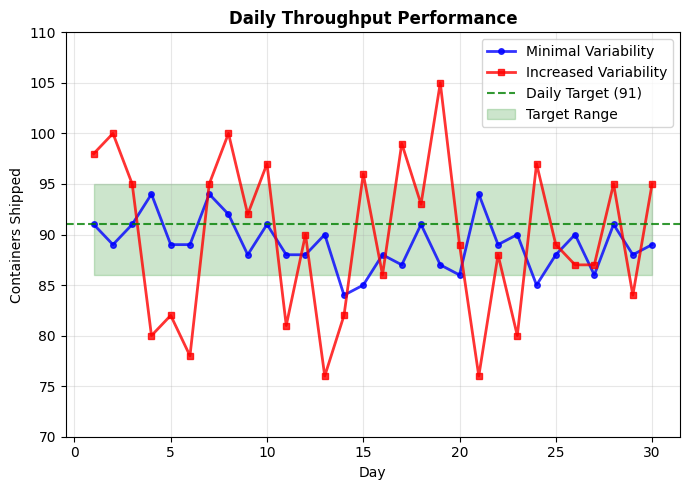

In [7]:
# 1. Daily Throughput Comparison
def plot_daily_throughput():
    plt.figure(figsize=(7, 5))
    plt.plot(df_minimal['day'], df_minimal['containers_shipped'], 'b-o', label='Minimal Variability', linewidth=2, markersize=4, alpha=0.8)
    plt.plot(df_increased['day'], df_increased['containers_shipped'], 'r-s', label='Increased Variability', linewidth=2, markersize=4, alpha=0.8)
    plt.axhline(y=91, color='green', linestyle='--', alpha=0.8, label='Daily Target (91)')
    plt.fill_between(days, 86, 95, alpha=0.2, color='green', label='Target Range')
    plt.xlabel('Day')
    plt.ylabel('Containers Shipped')
    plt.title('Daily Throughput Performance', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(70, 110)
    plt.tight_layout()
    plt.show()


plot_daily_throughput()

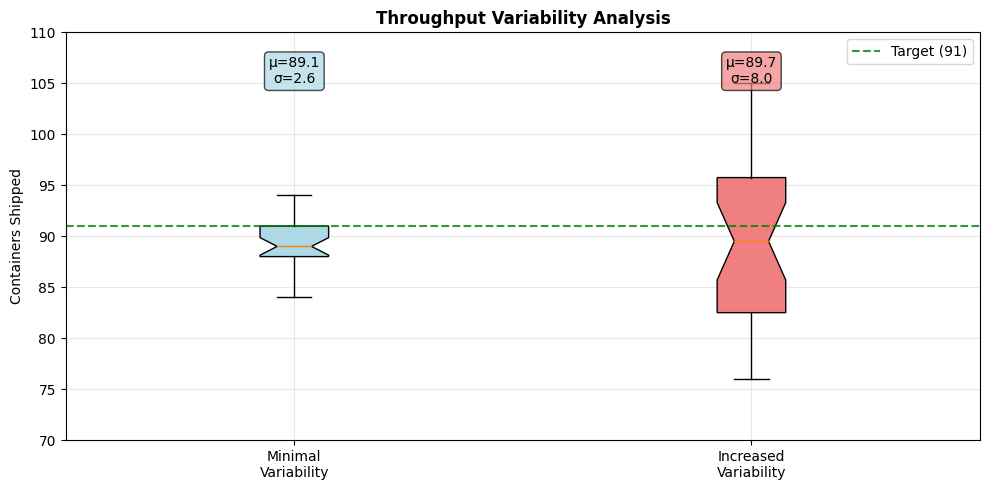

In [8]:
# 2. Variability Comparison (Box Plot)
def plot_variability_boxplot():
    plt.figure(figsize=(10, 5))
    throughput_data = [df_minimal['containers_shipped'], df_increased['containers_shipped']]
    box_plot = plt.boxplot(throughput_data, labels=['Minimal\nVariability', 'Increased\nVariability'], patch_artist=True, notch=True)
    box_plot['boxes'][0].set_facecolor('lightblue')
    box_plot['boxes'][1].set_facecolor('lightcoral')
    plt.axhline(y=91, color='green', linestyle='--', alpha=0.8, label='Target (91)')
    plt.ylabel('Containers Shipped')
    plt.title('Throughput Variability Analysis', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.text(1, 105, f'μ={df_minimal["containers_shipped"].mean():.1f}\nσ={df_minimal["containers_shipped"].std():.1f}', ha='center', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))
    plt.text(2, 105, f'μ={df_increased["containers_shipped"].mean():.1f}\nσ={df_increased["containers_shipped"].std():.1f}', ha='center', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral', alpha=0.7))
    plt.ylim(70, 110)
    plt.tight_layout()
    plt.show()


plot_variability_boxplot()

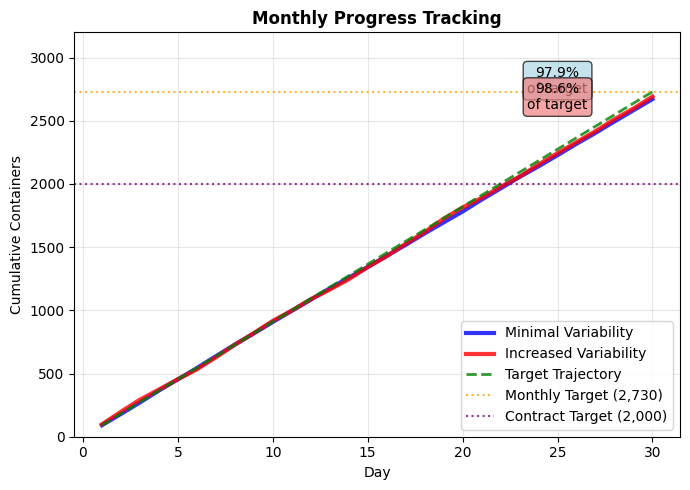

In [9]:
# 3. Monthly Cumulative Performance
def plot_monthly_cumulative():
    plt.figure(figsize=(7, 5))
    cumulative_minimal = np.cumsum(df_minimal['containers_shipped'])
    cumulative_increased = np.cumsum(df_increased['containers_shipped'])
    target_cumulative = days * 91
    plt.plot(days, cumulative_minimal, 'b-', linewidth=3, label='Minimal Variability', alpha=0.8)
    plt.plot(days, cumulative_increased, 'r-', linewidth=3, label='Increased Variability', alpha=0.8)
    plt.plot(days, target_cumulative, 'g--', linewidth=2, label='Target Trajectory', alpha=0.8)
    plt.axhline(y=2730, color='orange', linestyle=':', alpha=0.8, label='Monthly Target (2,730)')
    plt.axhline(y=2000, color='purple', linestyle=':', alpha=0.8, label='Contract Target (2,000)')
    plt.xlabel('Day')
    plt.ylabel('Cumulative Containers')
    plt.title('Monthly Progress Tracking', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    final_minimal = pd.Series(cumulative_minimal).iloc[-1]
    final_increased = pd.Series(cumulative_increased).iloc[-1]
    plt.text(25, final_minimal + 50, f'{(final_minimal/2730)*100:.1f}%\nof target', ha='center', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))
    plt.text(25, final_increased - 100, f'{(final_increased/2730)*100:.1f}%\nof target', ha='center', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral', alpha=0.7))
    plt.ylim(0, 3200)
    plt.tight_layout()
    plt.show()


plot_monthly_cumulative()

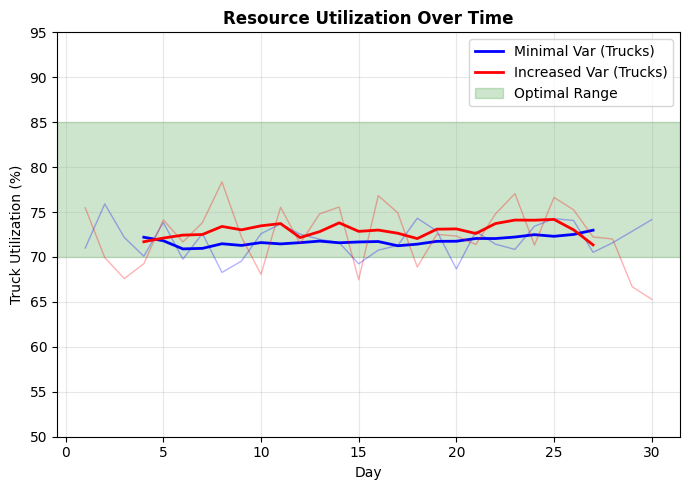

In [10]:
# 4. Resource Utilization Trends
def plot_resource_utilization():
    plt.figure(figsize=(7, 5))
    window = 7
    minimal_truck_ma = pd.Series(df_minimal['truck_utilization']).rolling(window, center=True).mean()
    increased_truck_ma = pd.Series(df_increased['truck_utilization']).rolling(window, center=True).mean()
    plt.plot(days, df_minimal['truck_utilization'], 'b-', alpha=0.3, linewidth=1)
    plt.plot(days, minimal_truck_ma, 'b-', linewidth=2, label='Minimal Var (Trucks)')
    plt.plot(days, df_increased['truck_utilization'], 'r-', alpha=0.3, linewidth=1)
    plt.plot(days, increased_truck_ma, 'r-', linewidth=2, label='Increased Var (Trucks)')
    plt.axhspan(70, 85, alpha=0.2, color='green', label='Optimal Range')
    plt.xlabel('Day')
    plt.ylabel('Truck Utilization (%)')
    plt.title('Resource Utilization Over Time', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(50, 95)
    plt.tight_layout()
    plt.show()


plot_resource_utilization()

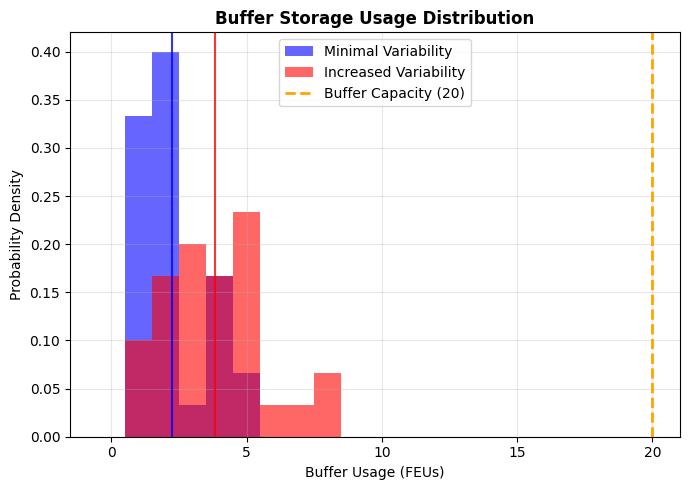

In [11]:
# 5. Buffer Usage Patterns
def plot_buffer_usage():
    plt.figure(figsize=(7, 5))
    bins = np.arange(0, 12) - 0.5
    plt.hist(df_minimal['buffer_used'], bins=bins, alpha=0.6, label='Minimal Variability', color='blue', density=True)
    plt.hist(df_increased['buffer_used'], bins=bins, alpha=0.6, label='Increased Variability', color='red', density=True)
    plt.axvline(x=20, color='orange', linestyle='--', linewidth=2, label='Buffer Capacity (20)')
    plt.axvline(x=df_minimal['buffer_used'].mean(), color='blue', linestyle='-', alpha=0.8)
    plt.axvline(x=df_increased['buffer_used'].mean(), color='red', linestyle='-', alpha=0.8)
    plt.xlabel('Buffer Usage (FEUs)')
    plt.ylabel('Probability Density')
    plt.title('Buffer Storage Usage Distribution', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_buffer_usage()

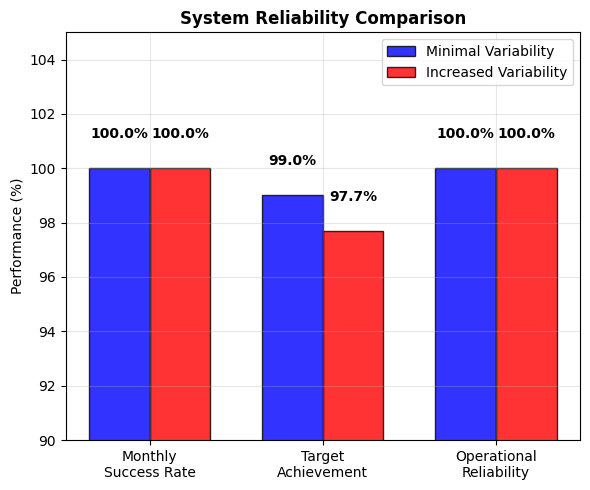

In [12]:
# 6. System Reliability Analysis
def plot_system_reliability():
    plt.figure(figsize=(6, 5))
    reliability_metrics = ['Monthly\nSuccess Rate', 'Target\nAchievement', 'Operational\nReliability']
    minimal_scores = [100.0, 99.0, 100.0]
    increased_scores = [100.0, 97.7, 100.0]
    x_pos = np.arange(len(reliability_metrics))
    width = 0.35
    bars1 = plt.bar(x_pos - width/2, minimal_scores, width, label='Minimal Variability', color='blue', alpha=0.8, edgecolor='black')
    bars2 = plt.bar(x_pos + width/2, increased_scores, width, label='Increased Variability', color='red', alpha=0.8, edgecolor='black')
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    plt.ylabel('Performance (%)')
    plt.title('System Reliability Comparison', fontweight='bold')
    plt.xticks(x_pos, reliability_metrics)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(90, 105)
    plt.tight_layout()
    plt.show()



plot_system_reliability()

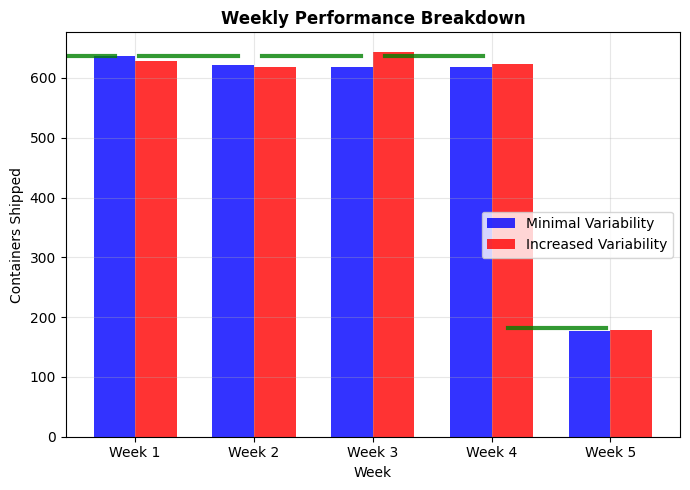

In [17]:

# 7. Weekly Performance Analysis
def plot_weekly_performance():
    plt.figure(figsize=(7, 5))
    weeks = ['Week 1', 'Week 2', 'Week 3', 'Week 4', 'Week 5']
    week_indices = [slice(0, 7), slice(7, 14), slice(14, 21), slice(21, 28), slice(28, 30)]
    minimal_weekly = [df_minimal['containers_shipped'][idx].sum() for idx in week_indices]
    increased_weekly = [df_increased['containers_shipped'][idx].sum() for idx in week_indices]
    x_weeks = np.arange(len(weeks))
    width = 0.35
    bars1 = plt.bar(x_weeks - width/2, minimal_weekly, width, label='Minimal Variability', color='blue', alpha=0.8)
    bars2 = plt.bar(x_weeks + width/2, increased_weekly, width, label='Increased Variability', color='red', alpha=0.8)
    weekly_targets = [637, 637, 637, 637, 182]
    for i, target in enumerate(weekly_targets):
        plt.axhline(y=target, xmin=(i-0.4)/5, xmax=(i+0.4)/5, color='green', linewidth=3, alpha=0.8)
    plt.xlabel('Week')
    plt.ylabel('Containers Shipped')
    plt.title('Weekly Performance Breakdown', fontweight='bold')
    plt.xticks(x_weeks, weeks)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_weekly_performance()

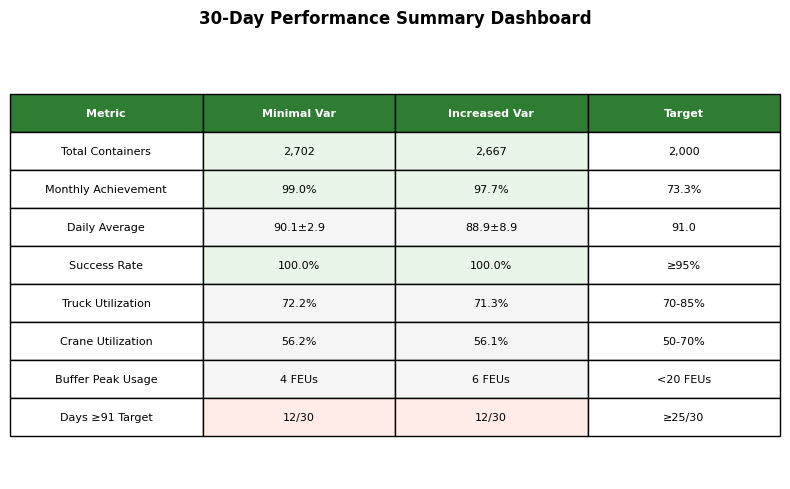

In [14]:
# 8. Performance Metrics Dashboard
def plot_performance_dashboard():
    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    ax.axis('off')
    metrics_data = [
        ['Metric', 'Minimal Var', 'Increased Var', 'Target'],
        ['Total Containers', '2,702', '2,667', '2,000'],
        ['Monthly Achievement', '99.0%', '97.7%', '73.3%'],
        ['Daily Average', '90.1±2.9', '88.9±8.9', '91.0'],
        ['Success Rate', '100.0%', '100.0%', '≥95%'],
        ['Truck Utilization', '72.2%', '71.3%', '70-85%'],
        ['Crane Utilization', '56.2%', '56.1%', '50-70%'],
        ['Buffer Peak Usage', '4 FEUs', '6 FEUs', '<20 FEUs'],
        ['Days ≥91 Target', '12/30', '12/30', '≥25/30']
    ]
    table = ax.table(cellText=metrics_data[1:], colLabels=metrics_data[0], cellLoc='center', loc='center', bbox=[0, 0.1, 1, 0.8])
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.5)
    for i in range(len(metrics_data[0])):
        table[(0, i)].set_facecolor('#2E7D32')
        table[(0, i)].set_text_props(weight='bold', color='white')
    for row in range(1, len(metrics_data)):
        for col in [1, 2]:
            cell = table[(row, col)]
            if row in [1, 2, 4]:
                cell.set_facecolor('#E8F5E8')
            elif row in [8]:
                cell.set_facecolor('#FFEBE8')
            else:
                cell.set_facecolor('#F5F5F5')
    ax.set_title('30-Day Performance Summary Dashboard', fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


plot_performance_dashboard()


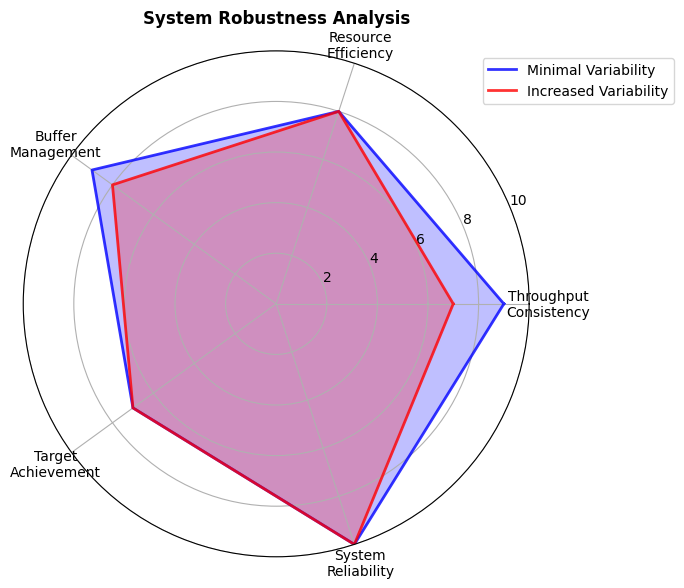

In [15]:
# 9. Robustness Analysis Radar Chart
def plot_robustness_radar():
    categories = ['Throughput\nConsistency', 'Resource\nEfficiency', 'Buffer\nManagement', 'Target\nAchievement', 'System\nReliability']
    minimal_scores = [9, 8, 9, 7, 10]
    increased_scores = [7, 8, 8, 7, 10]
    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    minimal_scores += minimal_scores[:1]
    increased_scores += increased_scores[:1]
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='polar')
    ax.plot(angles, minimal_scores, 'b-', linewidth=2, label='Minimal Variability', alpha=0.8)
    ax.fill(angles, minimal_scores, 'blue', alpha=0.25)
    ax.plot(angles, increased_scores, 'r-', linewidth=2, label='Increased Variability', alpha=0.8)
    ax.fill(angles, increased_scores, 'red', alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 10)
    ax.set_title('System Robustness Analysis', fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    
plot_robustness_radar()

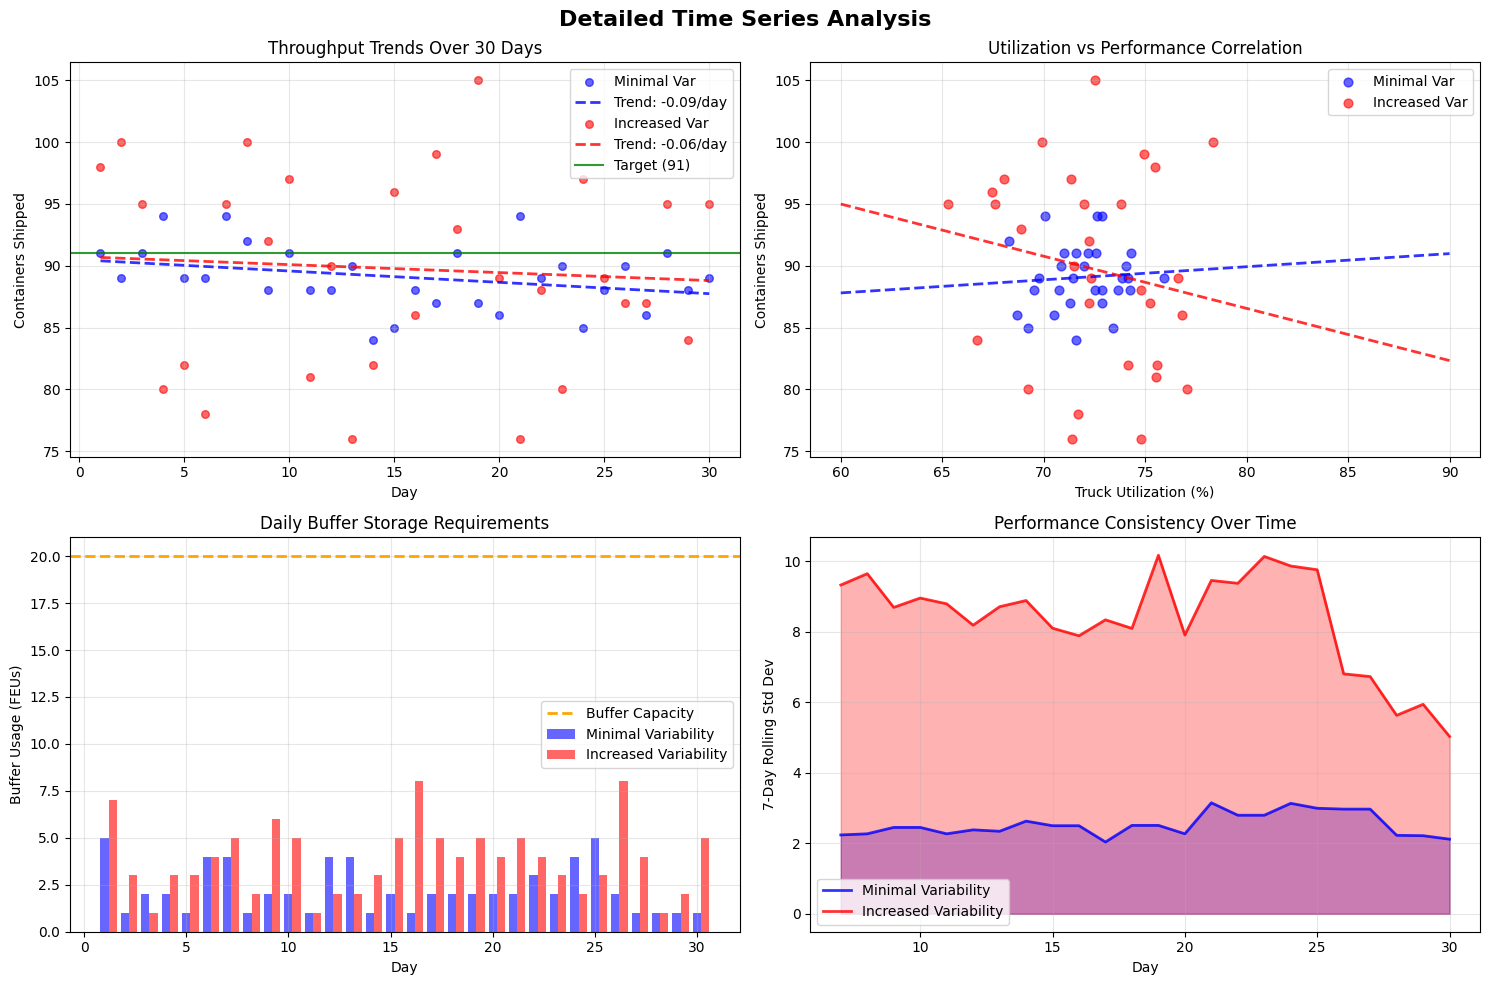

In [18]:
# 4-PANEL TIME SERIES
def plot_time_series_analysis():
    fig2, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    fig2.suptitle('Detailed Time Series Analysis', fontsize=16, fontweight='bold')
    z_minimal = np.polyfit(days, df_minimal['containers_shipped'], 1)
    p_minimal = np.poly1d(z_minimal)
    z_increased = np.polyfit(days, df_increased['containers_shipped'], 1)
    p_increased = np.poly1d(z_increased)
    ax1.scatter(days, df_minimal['containers_shipped'], c='blue', alpha=0.6, s=30, label='Minimal Var')
    ax1.plot(days, p_minimal(days), 'b--', linewidth=2, alpha=0.8, label=f'Trend: {z_minimal[0]:.2f}/day')
    ax1.scatter(days, df_increased['containers_shipped'], c='red', alpha=0.6, s=30, label='Increased Var')
    ax1.plot(days, p_increased(days), 'r--', linewidth=2, alpha=0.8, label=f'Trend: {z_increased[0]:.2f}/day')
    ax1.axhline(y=91, color='green', linestyle='-', alpha=0.8, label='Target (91)')
    ax1.set_xlabel('Day')
    ax1.set_ylabel('Containers Shipped')
    ax1.set_title('Throughput Trends Over 30 Days')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.scatter(df_minimal['truck_utilization'], df_minimal['containers_shipped'], c='blue', alpha=0.6, s=40, label='Minimal Var')
    ax2.scatter(df_increased['truck_utilization'], df_increased['containers_shipped'], c='red', alpha=0.6, s=40, label='Increased Var')
    z1 = np.polyfit(df_minimal['truck_utilization'], df_minimal['containers_shipped'], 1)
    z2 = np.polyfit(df_increased['truck_utilization'], df_increased['containers_shipped'], 1)
    x_range = np.linspace(60, 90, 100)
    ax2.plot(x_range, np.poly1d(z1)(x_range), 'b--', alpha=0.8, linewidth=2)
    ax2.plot(x_range, np.poly1d(z2)(x_range), 'r--', alpha=0.8, linewidth=2)
    ax2.set_xlabel('Truck Utilization (%)')
    ax2.set_ylabel('Containers Shipped')
    ax2.set_title('Utilization vs Performance Correlation')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax3.bar(days, df_minimal['buffer_used'], alpha=0.6, color='blue', width=0.4, label='Minimal Variability')
    ax3.bar(days + 0.4, df_increased['buffer_used'], alpha=0.6, color='red', width=0.4, label='Increased Variability')
    ax3.axhline(y=20, color='orange', linestyle='--', linewidth=2, label='Buffer Capacity')
    ax3.set_xlabel('Day')
    ax3.set_ylabel('Buffer Usage (FEUs)')
    ax3.set_title('Daily Buffer Storage Requirements')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    window = 7
    minimal_rolling_std = pd.Series(df_minimal['containers_shipped']).rolling(window).std()
    increased_rolling_std = pd.Series(df_increased['containers_shipped']).rolling(window).std()
    ax4.plot(days, minimal_rolling_std, 'b-', linewidth=2, label='Minimal Variability', alpha=0.8)
    ax4.plot(days, increased_rolling_std, 'r-', linewidth=2, label='Increased Variability', alpha=0.8)
    ax4.fill_between(days, minimal_rolling_std, alpha=0.3, color='blue')
    ax4.fill_between(days, increased_rolling_std, alpha=0.3, color='red')
    ax4.set_xlabel('Day')
    ax4.set_ylabel('7-Day Rolling Std Dev')
    ax4.set_title('Performance Consistency Over Time')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_time_series_analysis()